In [1]:
import pandas as pd



In [9]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [34]:
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin-1')
print(df.head())
print(df.columns)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [35]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [36]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [37]:
df = df.dropna()

In [38]:
print(df.duplicated().sum())

0


In [39]:
df = df.drop_duplicates()

In [40]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [41]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [42]:
df['Region'] = df['Region'].str.title()
df['Category'] = df['Category'].str.title()

In [43]:
print("Total Sales:", df['Sales'].sum())

Total Sales: 2297200.8603000003


In [44]:
print("Total Profit:", df['Profit'].sum())

Total Profit: 286397.0217


In [45]:
sales_region = df.groupby('Region')['Sales'].sum()
print(sales_region)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


In [46]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [47]:
df.to_csv("cleaned_superstore.csv", index=False)

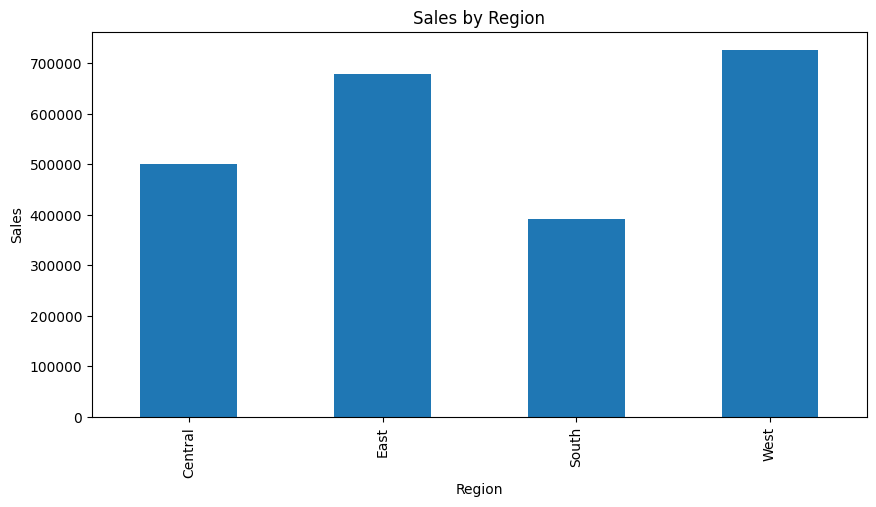

In [48]:
plt.figure(figsize=(10,5))
sales_region.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

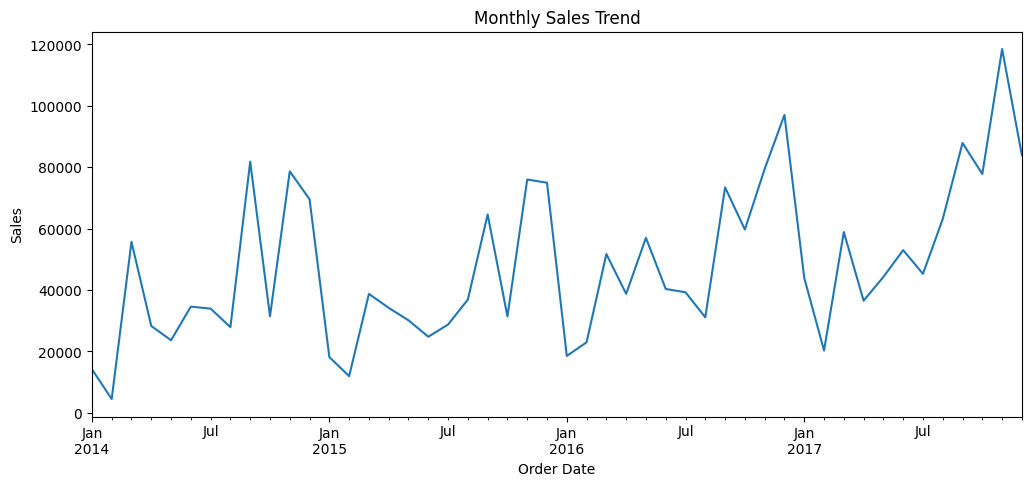

In [49]:
plt.figure(figsize=(12,5))
monthly_sales = df.set_index('Order Date')['Sales'].resample('MS').sum()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

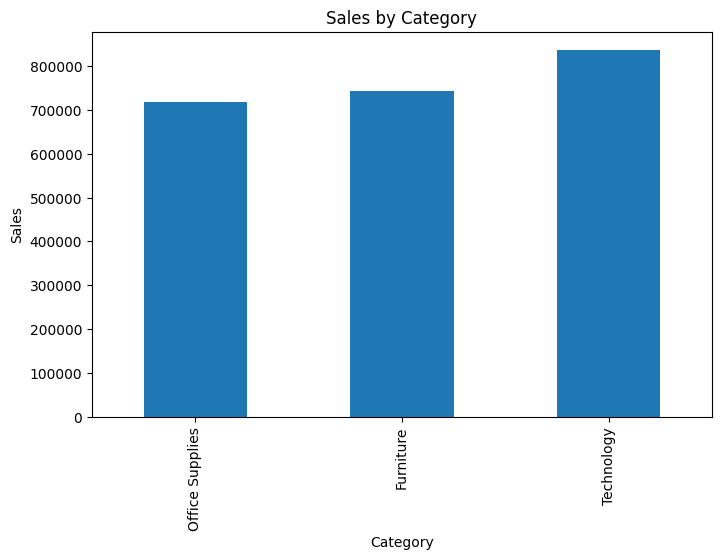

In [50]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

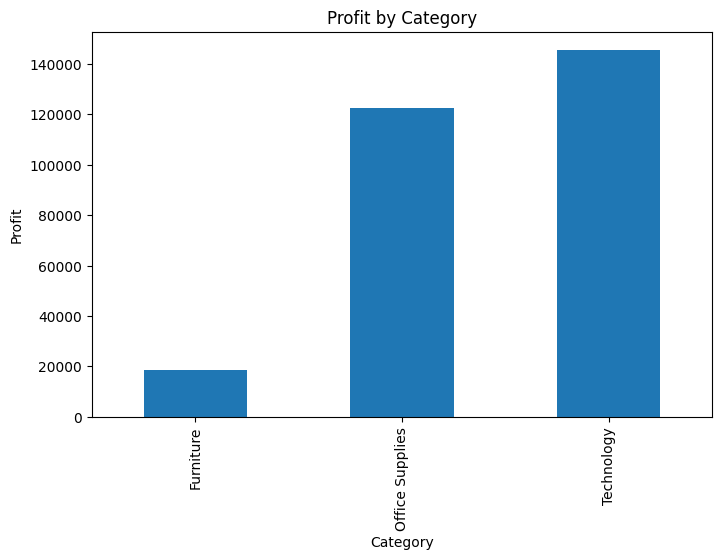

In [51]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Profit'].sum().sort_values().plot(kind='bar')
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

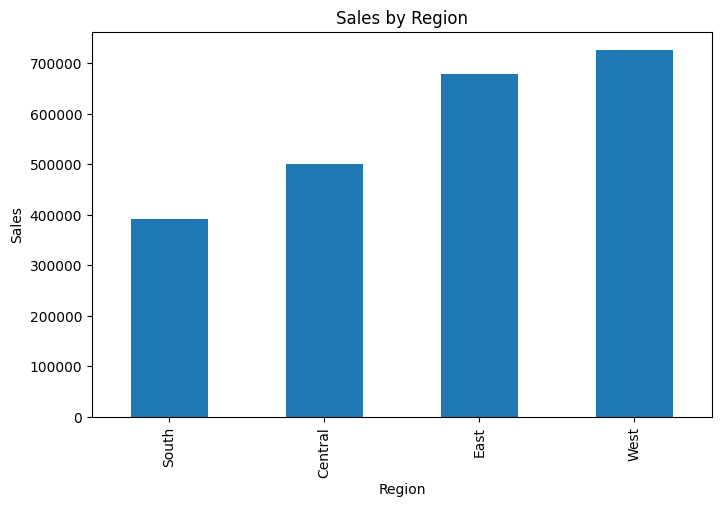

In [52]:
plt.figure(figsize=(8,5))
df.groupby('Region')['Sales'].sum().sort_values().plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

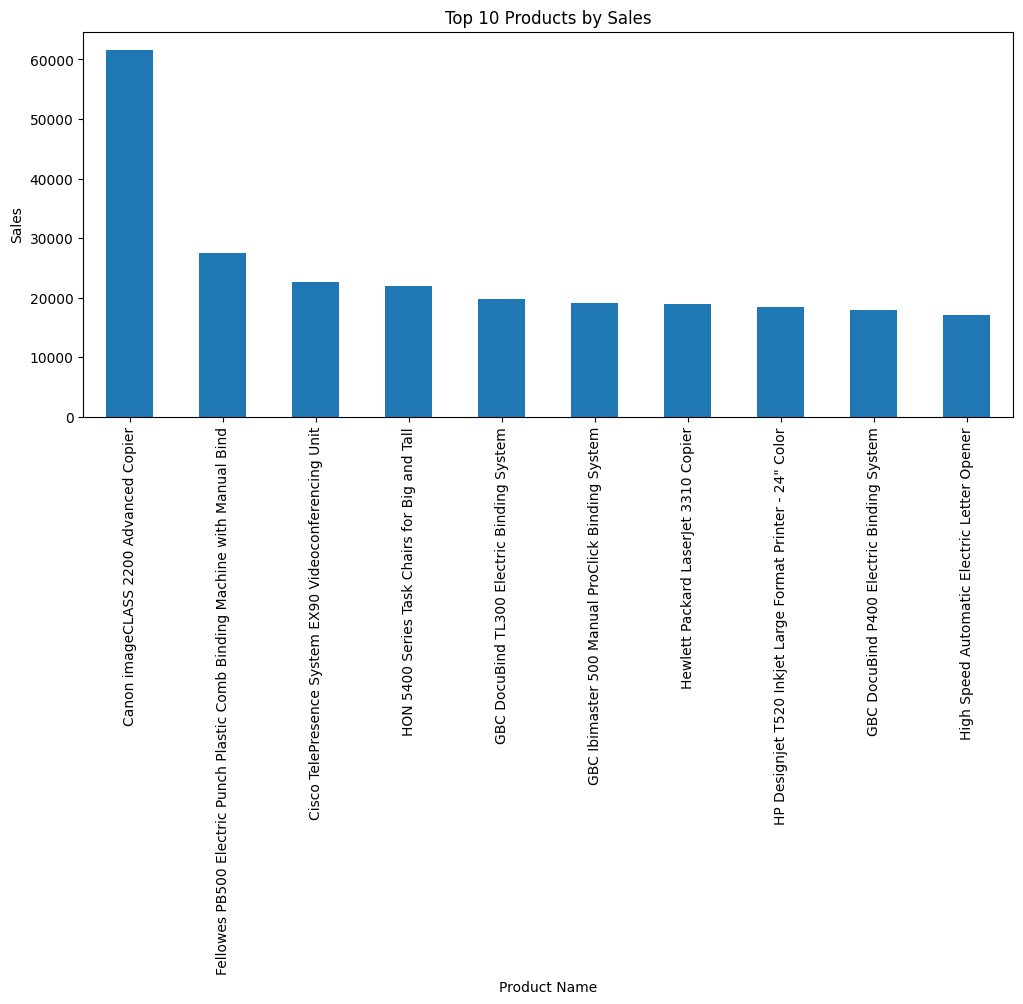

In [53]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")
plt.show()

In [54]:
print(df[['Sales','Profit','Quantity']].corr())

             Sales    Profit  Quantity
Sales     1.000000  0.479064  0.200795
Profit    0.479064  1.000000  0.066253
Quantity  0.200795  0.066253  1.000000


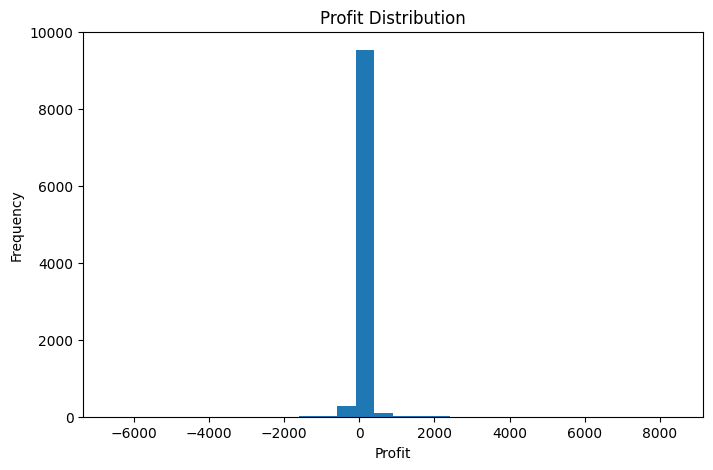

In [55]:
plt.figure(figsize=(8,5))
plt.hist(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

In [56]:
print("BUSINESS INSIGHTS")
print("-" * 50)

print("1. Total Sales:", round(df['Sales'].sum(),2))
print("2. Total Profit:", round(df['Profit'].sum(),2))

print("3. Top Region:",
      df.groupby('Region')['Sales'].sum().idxmax())

print("4. Top Category:",
      df.groupby('Category')['Sales'].sum().idxmax())

print("5. Most Profitable Category:",
      df.groupby('Category')['Profit'].sum().idxmax())

print("6. Best Customer Segment:",
      df.groupby('Segment')['Sales'].sum().idxmax())

BUSINESS INSIGHTS
--------------------------------------------------
1. Total Sales: 2297200.86
2. Total Profit: 286397.02
3. Top Region: West
4. Top Category: Technology
5. Most Profitable Category: Technology
6. Best Customer Segment: Consumer
